# Well log changepoint detection example

Online changepoint detection on the `well_log` dataset from the Turing Change
Point Dataset (TCPD), using `MeanCUSUMUnknownVariance` with a threshold
calibrated via circular block bootstrap on a training segment.

In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np

from gridcp import (
    GridDetector,
    calibrate_detector_threshold_false_alarm_from_data,
    reset_detector_state,
    with_calibrated_threshold,
)
from gridcp.scores import MeanCUSUMUnknownVariance

## Load data and annotators

In [6]:
DATA_DIR = "data/well_log"
DATASET = "well_log"

# Load data and ground truth
with open(f"{DATA_DIR}/{DATASET}.json") as f:
    d = json.load(f)
data = np.array(d["series"][0]["raw"], dtype=float)

with open(f"{DATA_DIR}/annotations.json") as f:
    annotations = json.load(f)
annotators = annotations[DATASET]

## Calibrate threshold via circular block bootstrap on training segment

In [10]:
# Calibrate threshold via circular block bootstrap on training segment
training_data = data[5:155]
score = MeanCUSUMUnknownVariance()
detector = GridDetector(score)
threshold = calibrate_detector_threshold_false_alarm_from_data(
    detector,
    training_data=training_data,
    false_alarm_probability=0.05,
    stream_len=len(training_data),
    n_paths=2000,
)
detector = with_calibrated_threshold(detector, threshold)
print(f"Calibrated threshold: {float(threshold[0]):.4f}")

Calibrated threshold: 2.8363


## Run detector (reset at alarm time)

In [12]:
# Run detector (reset at alarm time)
state = detector.init_state()
alarms = []
scores = []
offset = 0
for i, x in enumerate(data):
    state, output = detector.update(state, np.array([x]))
    scores.append(float(output["max_score"][0]))
    if output["alarm"]:
        cp_local = int(output["max_split_point"][0])
        alarms.append({"alarm_at": i, "cp_estimate": offset + cp_local})
        offset = i + 1
        state = reset_detector_state(state, detector)

detected_cps = [a["cp_estimate"] for a in alarms]
print(f"Detected {len(detected_cps)} CPs: {detected_cps}")

Detected 14 CPs: [173, 201, 236, 255, 280, 311, 342, 401, 412, 422, 432, 461, 469, 656]


## Two-panel figure

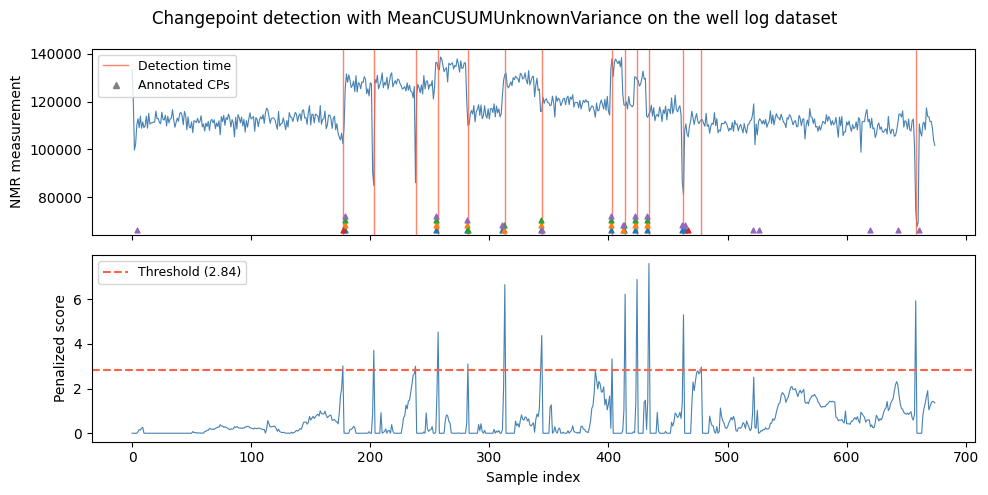

In [14]:
# Two-panel figure
colors = plt.cm.tab10.colors
thr = float(detector.threshold[0])

fig2, axes2 = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

# Top panel: raw data with stacked annotator triangles and alarm times
ax = axes2[0]
ax.plot(data, color="steelblue", linewidth=0.8)
for j, a in enumerate(alarms):
    ax.axvline(
        a["alarm_at"],
        color="tomato",
        linestyle="-",
        linewidth=1,
        alpha=0.8,
        label="Detection time" if j == 0 else None,
    )
cp_stack = {}
for k, (ann_id, cps) in enumerate(annotators.items()):
    for cp in cps:
        level = cp_stack.get(cp, 0)
        ax.scatter(
            cp,
            0.03 + level * 0.025,
            transform=ax.get_xaxis_transform(),
            s=12,
            marker="^",
            color=colors[k],
            zorder=3,
        )
        cp_stack[cp] = level + 1

ann_handle = plt.Line2D(
    [],
    [],
    marker="^",
    linestyle="none",
    markersize=5,
    color="grey",
    label="Annotated CPs",
)
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles=handles + [ann_handle],
    labels=labels + ["Annotated CPs"],
    loc="upper left",
    fontsize=9,
)
ax.set_ylabel("NMR measurement")

# Bottom panel: running max score with threshold
ax = axes2[1]
ax.plot(scores, color="steelblue", linewidth=0.8)
ax.axhline(
    thr,
    color="tomato",
    linestyle="--",
    linewidth=1.5,
    label=f"Threshold ({thr:.2f})",
)
ax.set_ylabel("Penalized score")
ax.set_xlabel("Sample index")
ax.legend(loc="upper left", fontsize=9)

plt.suptitle(
    "Changepoint detection with MeanCUSUMUnknownVariance on the well log dataset",
    fontsize=12,
)
plt.tight_layout()
#plt.savefig("well_log_stacked.pdf", bbox_inches="tight")
plt.show()